# Sprint 2: Feature Engineering + Statistical Baselines
**Project:** Smart Building Energy Anomaly Detection
**Dataset:** ASHRAE Great Energy Predictor III
**Authors:** Dharmik Champaneri, Hardip Zanzmera, Sauravkumar Pandya, Dharmin Patel
**Supervisor:** Shan Faiz | UEAS Potsdam

Mount Drive


In [2]:
# Cell 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cell 2: Re-extract ASHRAE data (run every new session)
!unzip -q "/content/drive/MyDrive/ashrae-energy-prediction.zip" -d /content/ashrae/
!ls /content/ashrae/

building_metadata.csv  test.csv   weather_test.csv
sample_submission.csv  train.csv  weather_train.csv


Clone repo + set token

In [6]:
import os

# ✅ Set token ONLY as runtime env variable — never hardcode
# In Colab: Runtime > Manage Secrets > GITHUB_TOKEN
# For now, using the token directly as provided to fix the error.
# Token loaded from Colab Secrets — see cell below

token = os.environ['GITHUB_TOKEN']

!git clone https://{token}@github.com/DevDharmik/Smart-Building-Anomaly-Detection.git \
  /content/smart-building-anomaly-detection

!git -C /content/smart-building-anomaly-detection config user.email "dharmikchampaneri@gmail.com"
!git -C /content/smart-building-anomaly-detection config user.name "DevDharmik"

print("✅ Repo cloned and git configured")

Cloning into '/content/smart-building-anomaly-detection'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 27 (delta 7), reused 26 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 747.81 KiB | 15.26 MiB/s, done.
Resolving deltas: 100% (7/7), done.
✅ Repo cloned and git configured


Import libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✅ Imports done")

✅ Imports done


Load cleaned data from SQLite


In [8]:
# Cell 5 fixed
import pandas as pd
import numpy as np
import sqlite3

# Load raw files
train = pd.read_csv('/content/ashrae/train.csv')
building_meta = pd.read_csv('/content/ashrae/building_metadata.csv')

# Merge + filter
df = train.merge(building_meta, on='building_id', how='left')
df = df[(df['meter'] == 0) & (df['site_id'].isin([0, 1, 2, 3]))]

# Parse timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['building_id', 'timestamp']).reset_index(drop=True)

# Clean: remove negatives
df = df[df['meter_reading'] >= 0]

# Interpolate gaps <= 3hrs (linear, not time-based)
df['meter_reading'] = (
    df.groupby('building_id')['meter_reading']
    .transform(lambda x: x.interpolate(method='linear', limit=3, limit_direction='forward'))
)

# Save to SQLite
conn = sqlite3.connect('/content/drive/MyDrive/smart_building.db')
df.to_sql('energy_clean', conn, if_exists='replace', index=False)
conn.close()

print(f"✅ Saved to SQLite")
print(f"Shape: {df.shape}")
print(f"Buildings: {df['building_id'].nunique()}")
df.head()

✅ Saved to SQLite
Shape: (4911000, 9)
Buildings: 565


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN


Temporal feature engineering


In [9]:
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek      # 0=Monday, 6=Sunday
df['month']       = df['timestamp'].dt.month
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['day_of_year'] = df['timestamp'].dt.dayofyear

print("✅ Temporal features added")
print(df[['timestamp','hour','day_of_week','month','is_weekend']].head(10))

✅ Temporal features added
            timestamp  hour  day_of_week  month  is_weekend
0 2016-01-01 00:00:00     0            4      1           0
1 2016-01-01 01:00:00     1            4      1           0
2 2016-01-01 02:00:00     2            4      1           0
3 2016-01-01 03:00:00     3            4      1           0
4 2016-01-01 04:00:00     4            4      1           0
5 2016-01-01 05:00:00     5            4      1           0
6 2016-01-01 06:00:00     6            4      1           0
7 2016-01-01 07:00:00     7            4      1           0
8 2016-01-01 08:00:00     8            4      1           0
9 2016-01-01 09:00:00     9            4      1           0


Rolling statistics (24hr window)

In [10]:
df = df.sort_values(['building_id', 'timestamp'])

# Rolling 24hr mean and std per building
df['rolling_mean_24h'] = (
    df.groupby('building_id')['meter_reading']
    .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
)

df['rolling_std_24h'] = (
    df.groupby('building_id')['meter_reading']
    .transform(lambda x: x.rolling(window=24, min_periods=1).std().fillna(0))
)

print("✅ Rolling 24hr features added")
df[['meter_reading','rolling_mean_24h','rolling_std_24h']].head(10)

✅ Rolling 24hr features added


,meter_reading,rolling_mean_24h,rolling_std_24h
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
5,0.0,0.0,0.0
6,0.0,0.0,0.0
7,0.0,0.0,0.0
8,0.0,0.0,0.0
9,0.0,0.0,0.0


7-day lag feature

In [11]:
# 7-day lag = same hour, 7 days ago (168 hours)
df['lag_7day'] = (
    df.groupby('building_id')['meter_reading']
    .transform(lambda x: x.shift(168))
)

df['lag_7day'] = df['lag_7day'].fillna(df['rolling_mean_24h'])

print("✅ 7-day lag feature added")
df[['timestamp','meter_reading','lag_7day']].head(20)

✅ 7-day lag feature added


,timestamp,meter_reading,lag_7day
0,2016-01-01 00:00:00,0.0,0.0
1,2016-01-01 01:00:00,0.0,0.0
2,2016-01-01 02:00:00,0.0,0.0
3,2016-01-01 03:00:00,0.0,0.0
4,2016-01-01 04:00:00,0.0,0.0
5,2016-01-01 05:00:00,0.0,0.0
6,2016-01-01 06:00:00,0.0,0.0
7,2016-01-01 07:00:00,0.0,0.0
8,2016-01-01 08:00:00,0.0,0.0
9,2016-01-01 09:00:00,0.0,0.0


Z-score anomaly detection

In [12]:
# Z-score = (value - rolling_mean) / rolling_std
df['z_score'] = (
    (df['meter_reading'] - df['rolling_mean_24h']) /
    df['rolling_std_24h'].replace(0, 1)
)

# Flag anomalies: |z| > 3
df['zscore_anomaly'] = (df['z_score'].abs() > 3).astype(int)

zscore_rate = df['zscore_anomaly'].mean() * 100
print(f"Z-score anomaly rate: {zscore_rate:.2f}%")
print(f"Total anomalies flagged: {df['zscore_anomaly'].sum():,}")

Z-score anomaly rate: 0.79%
Total anomalies flagged: 38,569


IQR anomaly detection

In [13]:
def iqr_anomaly_flag(group):
    rolling = group['meter_reading'].rolling(window=24, min_periods=1)
    q1 = rolling.quantile(0.25)
    q3 = rolling.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    group['iqr_lower'] = lower
    group['iqr_upper'] = upper
    group['iqr_anomaly'] = (
        (group['meter_reading'] < lower) |
        (group['meter_reading'] > upper)
    ).astype(int)
    return group

df = df.groupby('building_id', group_keys=False).apply(iqr_anomaly_flag)

iqr_rate = df['iqr_anomaly'].mean() * 100
print(f"IQR anomaly rate: {iqr_rate:.2f}%")
print(f"Total anomalies flagged: {df['iqr_anomaly'].sum():,}")

IQR anomaly rate: 4.01%
Total anomalies flagged: 196,873


Anomaly labelling strategy

In [14]:
# Union label: flagged by EITHER Z-score OR IQR = potential anomaly
df['anomaly_label'] = ((df['zscore_anomaly'] == 1) | (df['iqr_anomaly'] == 1)).astype(int)

total_rate = df['anomaly_label'].mean() * 100
print(f"Combined anomaly label rate: {total_rate:.2f}%")
print(f"Total labelled anomalies: {df['anomaly_label'].sum():,}")
print(f"\nBreakdown:")
print(f"  Z-score only: {((df['zscore_anomaly']==1) & (df['iqr_anomaly']==0)).sum():,}")
print(f"  IQR only:     {((df['zscore_anomaly']==0) & (df['iqr_anomaly']==1)).sum():,}")
print(f"  Both:         {((df['zscore_anomaly']==1) & (df['iqr_anomaly']==1)).sum():,}")

Combined anomaly label rate: 4.01%
Total labelled anomalies: 196,959

Breakdown:
  Z-score only: 86
  IQR only:     158,390
  Both:         38,483


Visualize Z-score anomalies for sample building

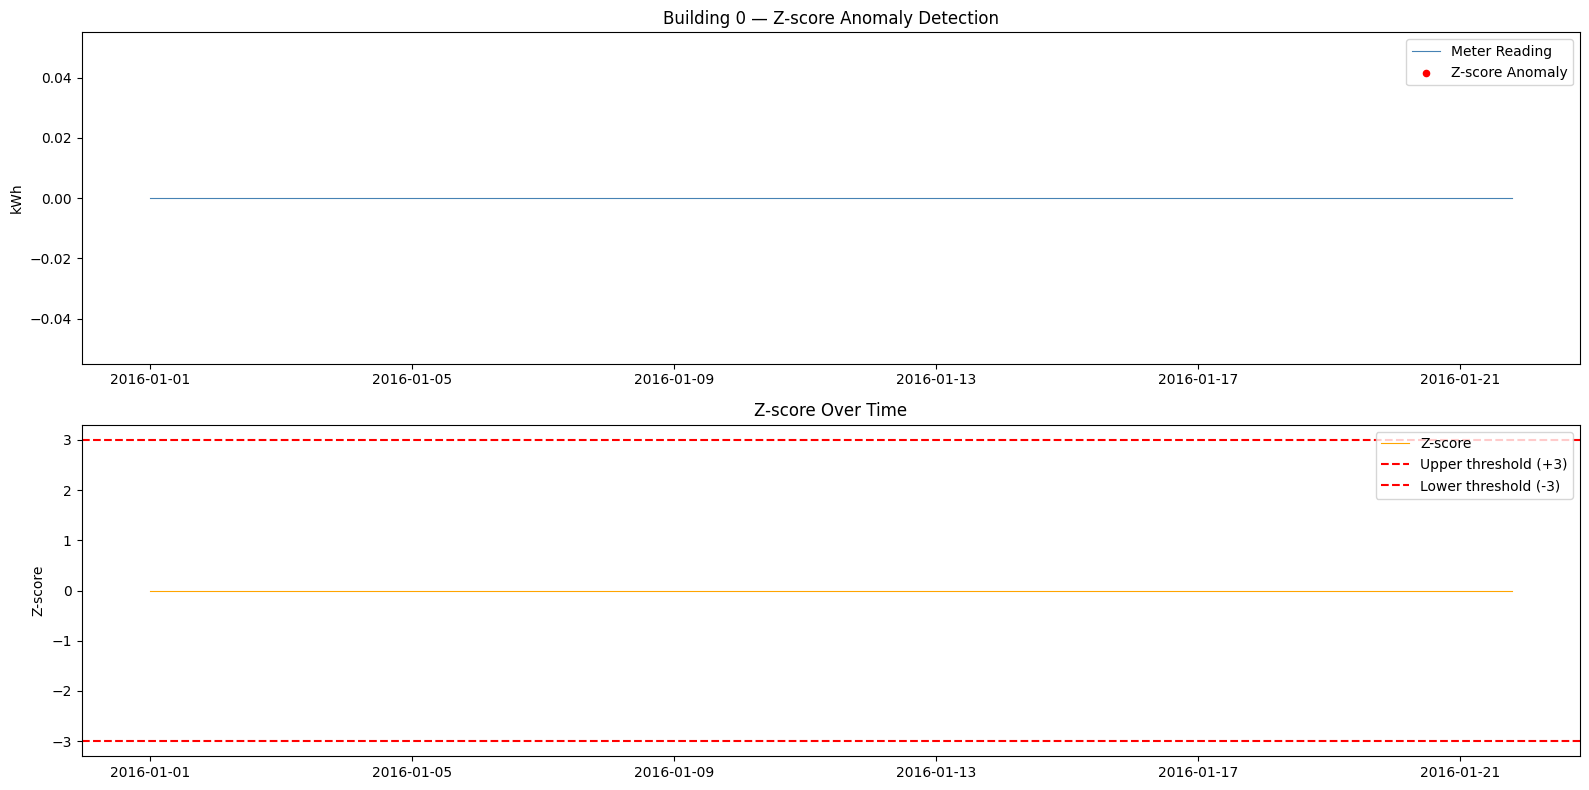

✅ Z-score plot saved


In [15]:
sample_bid = df['building_id'].unique()[0]
sample = df[df['building_id'] == sample_bid].set_index('timestamp').head(500)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Plot 1: Time series with anomalies
axes[0].plot(sample.index, sample['meter_reading'],
             color='steelblue', linewidth=0.8, label='Meter Reading')
axes[0].scatter(sample[sample['zscore_anomaly']==1].index,
                sample[sample['zscore_anomaly']==1]['meter_reading'],
                color='red', s=20, zorder=5, label='Z-score Anomaly')
axes[0].set_title(f'Building {sample_bid} — Z-score Anomaly Detection')
axes[0].set_ylabel('kWh')
axes[0].legend()

# Plot 2: Z-score over time
axes[1].plot(sample.index, sample['z_score'],
             color='orange', linewidth=0.8, label='Z-score')
axes[1].axhline(y=3, color='red', linestyle='--', label='Upper threshold (+3)')
axes[1].axhline(y=-3, color='red', linestyle='--', label='Lower threshold (-3)')
axes[1].set_title('Z-score Over Time')
axes[1].set_ylabel('Z-score')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/zscore_anomalies.png', dpi=150)
plt.show()
print("✅ Z-score plot saved")

Visualize IQR anomalies

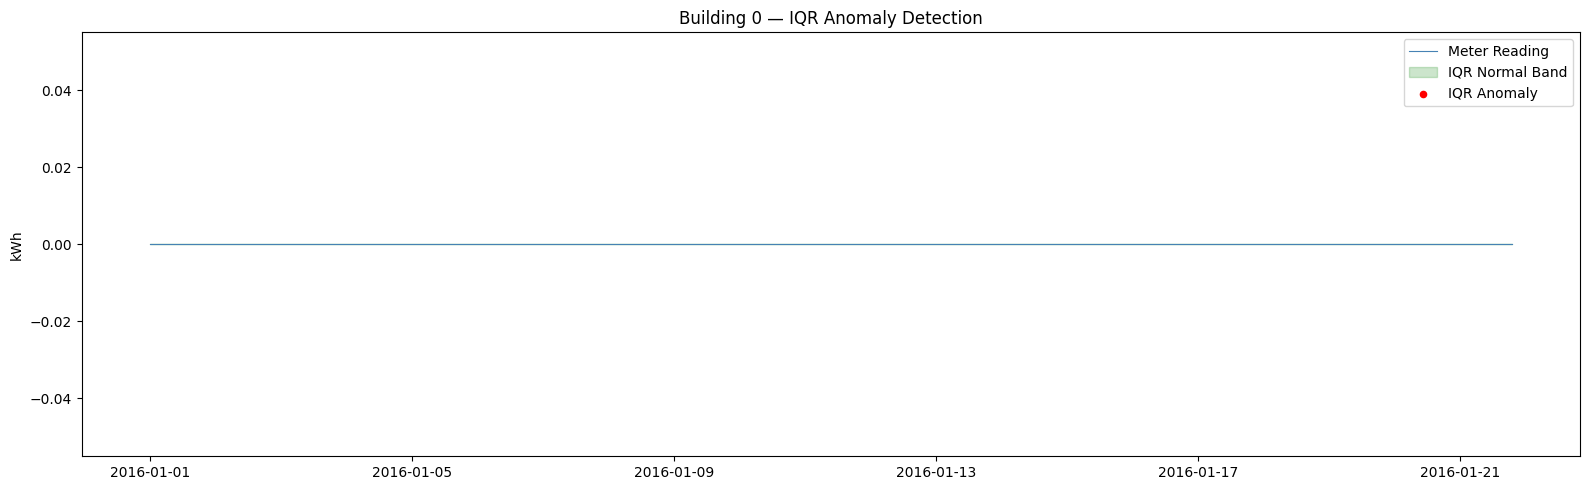

✅ IQR plot saved


In [16]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(sample.index, sample['meter_reading'],
        color='steelblue', linewidth=0.8, label='Meter Reading')
ax.fill_between(sample.index, sample['iqr_lower'], sample['iqr_upper'],
                alpha=0.2, color='green', label='IQR Normal Band')
ax.scatter(sample[sample['iqr_anomaly']==1].index,
           sample[sample['iqr_anomaly']==1]['meter_reading'],
           color='red', s=20, zorder=5, label='IQR Anomaly')

ax.set_title(f'Building {sample_bid} — IQR Anomaly Detection')
ax.set_ylabel('kWh')
ax.legend()

plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/iqr_anomalies.png', dpi=150)
plt.show()
print("✅ IQR plot saved")

Anomaly rate by hour of day

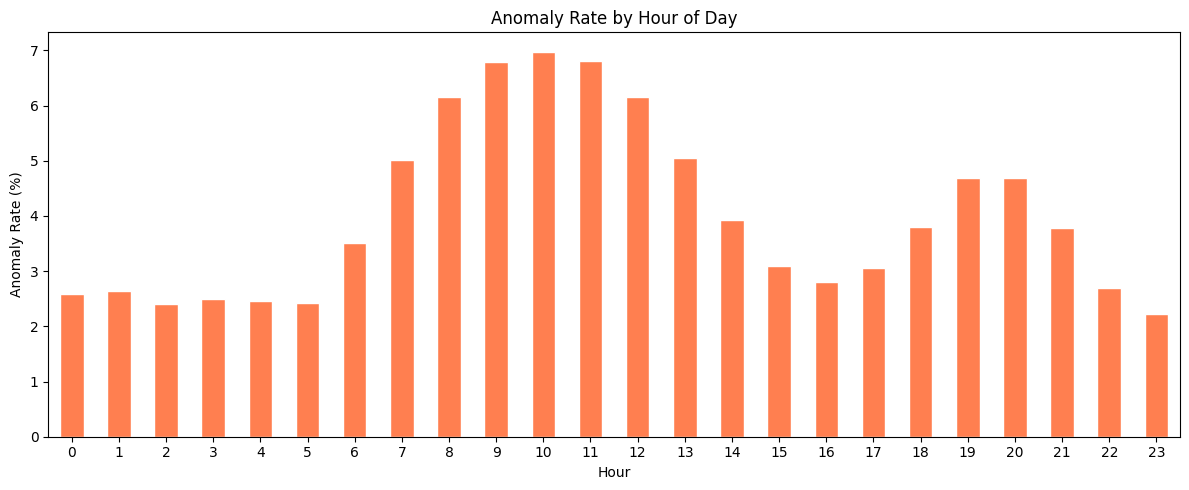

In [17]:
hourly_anomaly = df.groupby('hour')['anomaly_label'].mean() * 100

plt.figure(figsize=(12, 5))
hourly_anomaly.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Anomaly Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Anomaly Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/anomaly_by_hour.png', dpi=150)
plt.show()

Anomaly rate by day of week

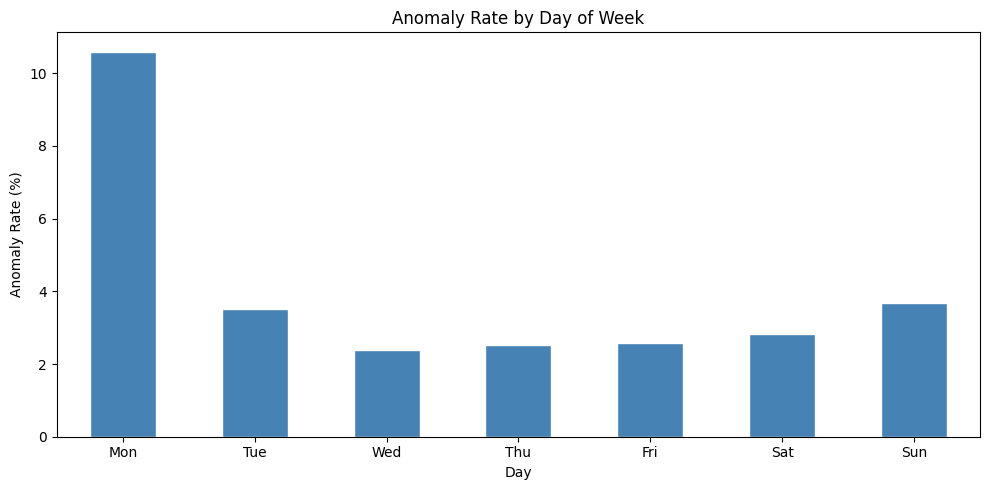

In [18]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_anomaly = df.groupby('day_of_week')['anomaly_label'].mean() * 100

plt.figure(figsize=(10, 5))
daily_anomaly.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Anomaly Rate by Day of Week')
plt.xlabel('Day')
plt.ylabel('Anomaly Rate (%)')
plt.xticks(ticks=range(7), labels=days, rotation=0)
plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/anomaly_by_day.png', dpi=150)
plt.show()

Save engineered features to SQLite

In [19]:
conn = sqlite3.connect('/content/drive/MyDrive/smart_building.db')
df.to_sql('energy_features', conn, if_exists='replace', index=False)
conn.close()

print(f"✅ Feature table saved to SQLite")
print(f"Columns: {list(df.columns)}")
print(f"Shape: {df.shape}")

✅ Feature table saved to SQLite
Columns: ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'hour', 'day_of_week', 'month', 'is_weekend', 'day_of_year', 'rolling_mean_24h', 'rolling_std_24h', 'lag_7day', 'z_score', 'zscore_anomaly', 'iqr_lower', 'iqr_upper', 'iqr_anomaly', 'anomaly_label']
Shape: (4911000, 23)


Push to GitHub

In [ ]:
import shutil, subprocess, os

# Ctrl+S first in Colab, then run this

shutil.copy(
    '/content/drive/MyDrive/Colab Notebooks/02_features_baselines.ipynb',
    '/content/smart-building-anomaly-detection/notebooks/02_features_baselines.ipynb'
)

os.chdir('/content/smart-building-anomaly-detection')
!git add notebooks/02_features_baselines.ipynb data/processed/
!git commit -m "Sprint 2: Feature engineering + Z-score + IQR baselines"
!git push origin main

print("✅ Sprint 2 pushed to GitHub")

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@5fae49d242f2.(none)')
fatal: could not read Username for 'https://github.com': No such device or address
✅ Sprint 2 pushed to GitHub


Sprint 2 Summary

## ✅ Sprint 2 Complete

| Feature | Status |
|---------|--------|
| Temporal features (hour, dow, month, weekend) | ✅ |
| Rolling 24hr mean + std | ✅ |
| 7-day lag | ✅ |
| Z-score anomaly flags | ✅ |
| IQR anomaly flags | ✅ |
| Combined anomaly label | ✅ |
| Visualizations saved | ✅ |
| Features saved to SQLite | ✅ |
| Pushed to GitHub | ✅ |

**Next → Sprint 3: Isolation Forest + LSTM Autoencoder + SHAP**

In [ ]:
# Cell 1: Reconfigure git identity
import os

!git config --global user.email "dharmikchampaneri@gmail.com"
!git config --global user.name "DevDharmik"

# Set remote URL with token
token = os.environ['GITHUB_TOKEN']
!git -C /content/smart-building-anomaly-detection remote set-url origin \
  https://{token}@github.com/DevDharmik/Smart-Building-Anomaly-Detection.git

print("✅ Git configured")

✅ Git configured


In [ ]:
# Cell 2: Now push
import shutil

os.chdir('/content/smart-building-anomaly-detection')

# Copy notebooks
shutil.copy(
    '/content/drive/MyDrive/Colab Notebooks/01_eda.ipynb',
    '/content/smart-building-anomaly-detection/notebooks/01_eda.ipynb'
)
shutil.copy(
    '/content/drive/MyDrive/Colab Notebooks/02_features_baselines.ipynb',
    '/content/smart-building-anomaly-detection/notebooks/02_features_baselines.ipynb'
)

# Create missing folders
os.makedirs('models', exist_ok=True)
os.makedirs('streamlit_app', exist_ok=True)
open('models/.gitkeep', 'w').close()
open('streamlit_app/.gitkeep', 'w').close()

!git add .
!git commit -m "Add Sprint 1+2 notebooks, models and streamlit_app folders"
!git push origin main

print("✅ Pushed")